In [19]:

import logging
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
# from decimal import Decimal
from datetime import datetime, timezone

import matplotlib.pyplot as plt
from scipy import stats



In [20]:

class AvailableDatasets:
    """Available Datasets, returns request ID"""

    FULL_YEAR_2024__CME_JPY_V: str = "GLBX-20251028-HAE9P7SP3U"
    FULL_YEAR_2023__CME_JPY_V: str = "GLBX-20251116-MJ5JKQA9A4"
    FULL_YEAR_2022__CME_JPY_V: str = "GLBX-20251115-DJHUGKSLWB"


In [21]:

# WORKING DIRECTORY
MAIN_DIR = Path("/Users/number6/Projects/Bimini/")

# HISTORICAL DATA
HISTORICAL_DATA = MAIN_DIR / "0_data" / "historical"

# IMPORT PATH
PARQUET_DIR = HISTORICAL_DATA / "parquet"

# EXPORT PATH
EXPORT_DIR = MAIN_DIR / "journal_results"


In [22]:


"""

2024-04-07 | Series of Carry-Trade Squeezes

**Date:** April through July 2024  
**Time:** Multiple episodes, primarily Tokyo hours (00:00-06:00 GMT)  
**UTC Time:** 00:00-06:00 UTC  

"""



TICK_SIZE = 0.00001




# Convert START_DATE and END_DATE to nanosecond epochs (integers)
START_DATE_NS = int(
    datetime(
        year=2024,
        month=4,
        day=28,
        hour=22,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)

END_DATE_NS = int(
    datetime(
        year=2024,
        month=4,
        day=29,
        hour=12,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)


hrf_start_dt = datetime.fromtimestamp(START_DATE_NS / 1e9, tz=timezone.utc)
hrf_end_dt = datetime.fromtimestamp(END_DATE_NS / 1e9, tz=timezone.utc)

print("START_DATE_NS", hrf_start_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))
print("END_DATE_NS", hrf_end_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))



START_DATE_NS 2024-04-28 22:00:00 UTC
END_DATE_NS 2024-04-29 12:00:00 UTC


In [23]:


# ============================================================================
# [START] - Import Filters
# ============================================================================



# # Data files to glob for processing
# DATA_GLOB = pl.scan_parquet(str(PARQUET_DIR / request_id / "*.parquet"))

# Method 2: List of glob patterns for MULTIPLE DIRECTORIES
DATA_GLOB = pl.scan_parquet([
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2022__CME_JPY_V / "*.parquet"),
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2023__CME_JPY_V / "*.parquet"),
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2024__CME_JPY_V / "*.parquet"),
])


# [ ACTUAL FILTER REQUEST FOR PROCESSING ]
lf = (

    # 0) Glob across all files in data directory
    DATA_GLOB
    
    # 1) Select only needed columns FIRST (reduces data volume)
    .select([
        "ts_recv",
        "price",
        "size",
        "side",
        "sequence",
        "instrument_id",
    ])

    # 2.) Convert to physical int representation (just stripping data, saved as int64 in Parquet file)
    .with_columns(
        pl.col("ts_recv").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("ts_recv"),
        pl.col("side").cast(pl.Categorical)
    )
    
    # 3) Filter on raw uint64 epoch values (fastest)
    .filter(
        (pl.col("ts_recv") >= START_DATE_NS) & 
        (pl.col("ts_recv") < END_DATE_NS)
    )
    .filter(pl.col("side").is_in(["A", "B"])) # Remove "N" side orders
    # .limit(1_000)

)

In [24]:
request_data = (
    lf.select([
        pl.len().alias("total_rows"),
        pl.col("size").sum().alias("total_size"),
        pl.col("ts_recv").min().alias("ts_min"),
        pl.col("ts_recv").max().alias("ts_max"),
    ])
    .collect()
    .with_columns([
        pl.from_epoch("ts_min", time_unit="ns").dt.strftime("%A, %B %d, %Y at %H:%M UTC (%Y-%m-%d)").alias("date_min"),
        pl.from_epoch("ts_max", time_unit="ns").dt.strftime("%A, %B %d, %Y at %H:%M UTC (%Y-%m-%d)").alias("date_max"),
    ])
)

initial_date_min = request_data["date_min"][0]
initial_date_max = request_data["date_max"][0]

print(
    "[ REQUEST ]",
    f"\nSTART: {initial_date_min}",
    f"\nEND: {initial_date_max}",

)

[ REQUEST ] 
START: Sunday, April 28, 2024 at 22:00 UTC (2024-04-28) 
END: Monday, April 29, 2024 at 11:59 UTC (2024-04-29)


In [25]:
vwap = lf.with_columns(

    pl.col("ts_recv").cast(pl.Datetime("ns"))

).group_by_dynamic(

    "ts_recv",
    every="1m"

).agg(

    buy_vwap=(pl.col("size").filter(pl.col("side") == "B") * pl.col("price").filter(pl.col("side") == "B")).sum() / pl.col("size").filter(pl.col("side") == "B").sum(),
    sell_vwap=(pl.col("size").filter(pl.col("side") == "A") * pl.col("price").filter(pl.col("side") == "A")).sum() / pl.col("size").filter(pl.col("side") == "A").sum(),
    total_vwap=(pl.col("size") * pl.col("price")).sum() / pl.col("size").sum(),

).with_columns(

    spread=pl.col("buy_vwap") - pl.col("sell_vwap"),
    prev_total_vwap=pl.col("total_vwap").shift(1),
    total_vwap_change=pl.col("total_vwap") - pl.col("total_vwap").shift(1),
    pct_return=(pl.col("total_vwap") - pl.col("total_vwap").shift(1)) / pl.col("total_vwap").shift(1),

    # log(price_t) - log(price_t-1) = log(price_t / price_t-1) -> subtraction is more efficient
    log_return=pl.col("total_vwap").log() - pl.col("total_vwap").shift(1).log(),

    ts_recv_dt=pl.from_epoch(pl.col("ts_recv"), time_unit="ns"),
    Price=((pl.col("total_vwap") / 1e9)),

).select([
    
    "ts_recv",
    "buy_vwap",
    "sell_vwap",
    "total_vwap",
    "spread",
    "prev_total_vwap",
    "total_vwap_change",
    "pct_return",
    "log_return",
    "ts_recv_dt",
    "Price",

]).collect()


In [26]:
def plot_price(
    data: pl.DataFrame,
    symbol: str,
    tick_size: float,
) -> None:
    """
    Plot VWAP price over time.
    """

    price_min = data.select(pl.col("Price").min()).item()
    price_max = data.select(pl.col("Price").max()).item()

    print("data", data)
    print("price_min", price_min)
    print("price_max", price_max)
    
    y_tick_range = np.arange(
        price_min,
        price_max + tick_size,
        tick_size,
    )

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(
        data["ts_recv_dt"],
        data["Price"],
        drawstyle="steps-post",
    )

    plt.title(f"{symbol} Price")
    plt.xlabel("Time (UTC)")
    plt.ylabel("Price")
    plt.yticks(y_tick_range)
    plt.show()

data shape: (837, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ ts_recv   ┆ buy_vwap  ┆ sell_vwap ┆ total_vwa ┆ … ┆ pct_retur ┆ log_retur ┆ ts_recv_d ┆ Price    │
│ ---       ┆ ---       ┆ ---       ┆ p         ┆   ┆ n         ┆ n         ┆ t         ┆ ---      │
│ datetime[ ┆ f64       ┆ f64       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│ ns]       ┆           ┆           ┆ f64       ┆   ┆ f64       ┆ f64       ┆ datetime[ ┆          │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ ns]       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2024-04-2 ┆ 6.3761e6  ┆ 6.3763e6  ┆ 6.3762e6  ┆ … ┆ null      ┆ null      ┆ 2024-04-2 ┆ 0.006376 │
│ 8         ┆           ┆           ┆           ┆   ┆           ┆           ┆ 8         ┆          │
│ 22:00:00  ┆           ┆           ┆           ┆   ┆           ┆    

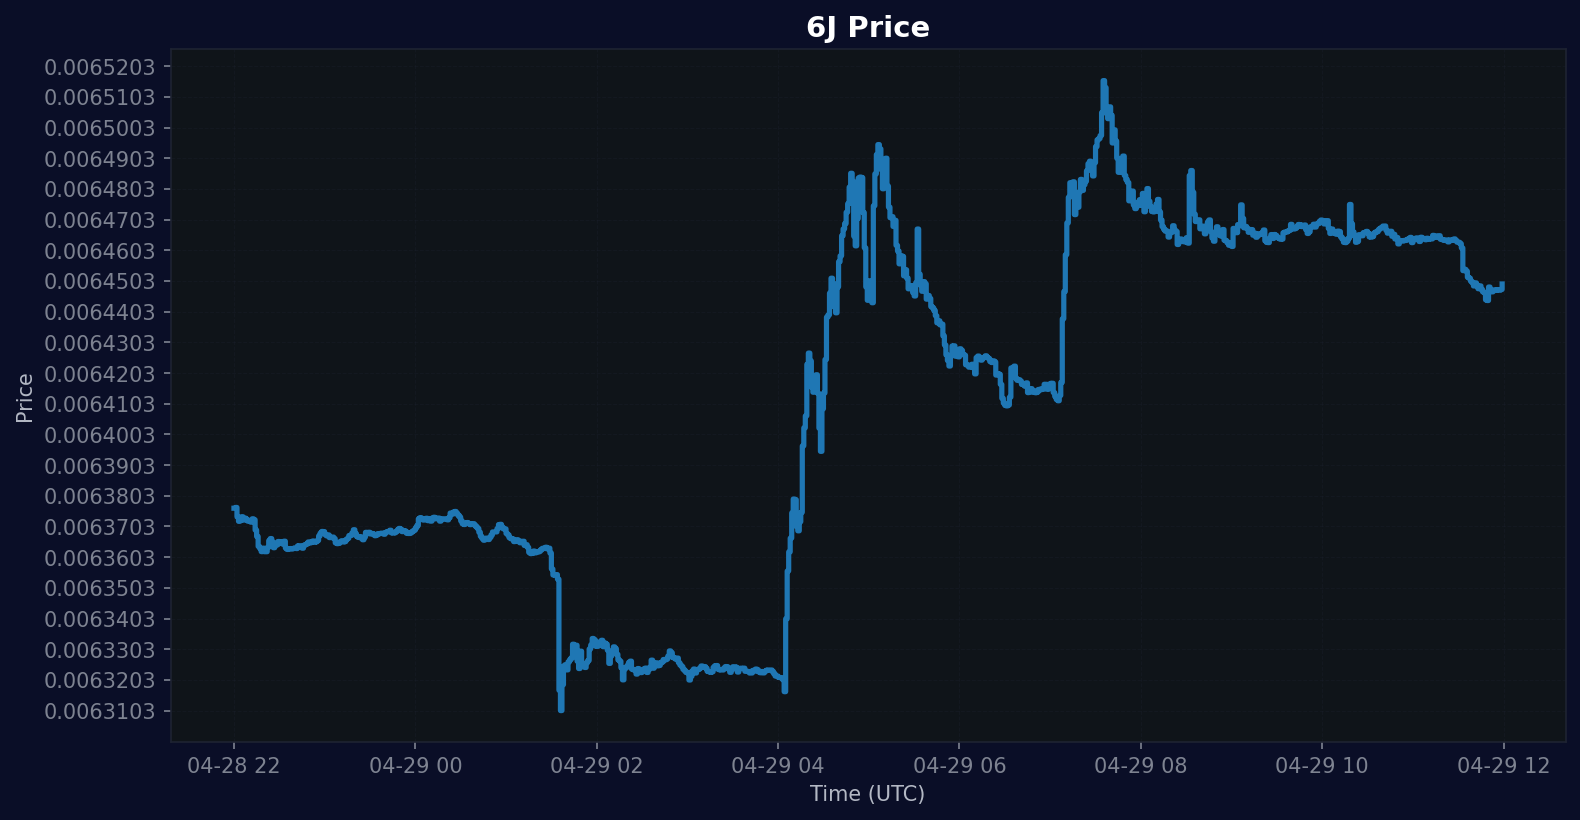

In [27]:
plot_price(vwap, "6J", TICK_SIZE)

In [28]:
"""

time elapsed start/end

OI....

"""

'\n\ntime elapsed start/end\n\nOI....\n\n'

In [29]:

VB100_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_ib1500/2214_Nov_15_25/volumebar/raw/volumebar_raw_consolidated.parquet")


# Data files to glob for processing
VB_DATA_GLOB = pl.scan_parquet(str(VB100_DIR))


# {VolumeBar 100} [ ACTUAL FILTER REQUEST FOR PROCESSING ]

vb_lf = (
    VB_DATA_GLOB
    .filter(
        (pl.col("start_ts_ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns") < END_DATE_NS)
    )
    .select([
        "id",
        "start_ts_ns",
        "end_ts_ns",
        "delta_midpoint_vwap_pct",
        "delta_midpoint_vwap_log",
        "time_elapsed_ns",
        "mid_aggressor_weighted",
    ])
    .with_columns(
        bucket=pl.int_range(pl.len()) // 50
    )
    .group_by("bucket")
    .agg([
        pl.col("start_ts_ns").first().alias("start_ts_ns"),
        pl.col("end_ts_ns").last().alias("end_ts_ns"),
        (pl.col("time_elapsed_ns").mean() / 1e9).alias("avg_time_elapsed_seconds"),
        (pl.col("time_elapsed_ns").sum() / 1e9).alias("total_time_elapsed_seconds"),
        pl.col("id").count().alias("bar_count"),
        pl.col("mid_aggressor_weighted").mean().alias("mid_aggressor_weighted"),
    ])
    .with_columns([
        pl.from_epoch(pl.col("start_ts_ns"), time_unit="ns").alias("start_time"),
    ])
    .sort("bucket")
).collect()

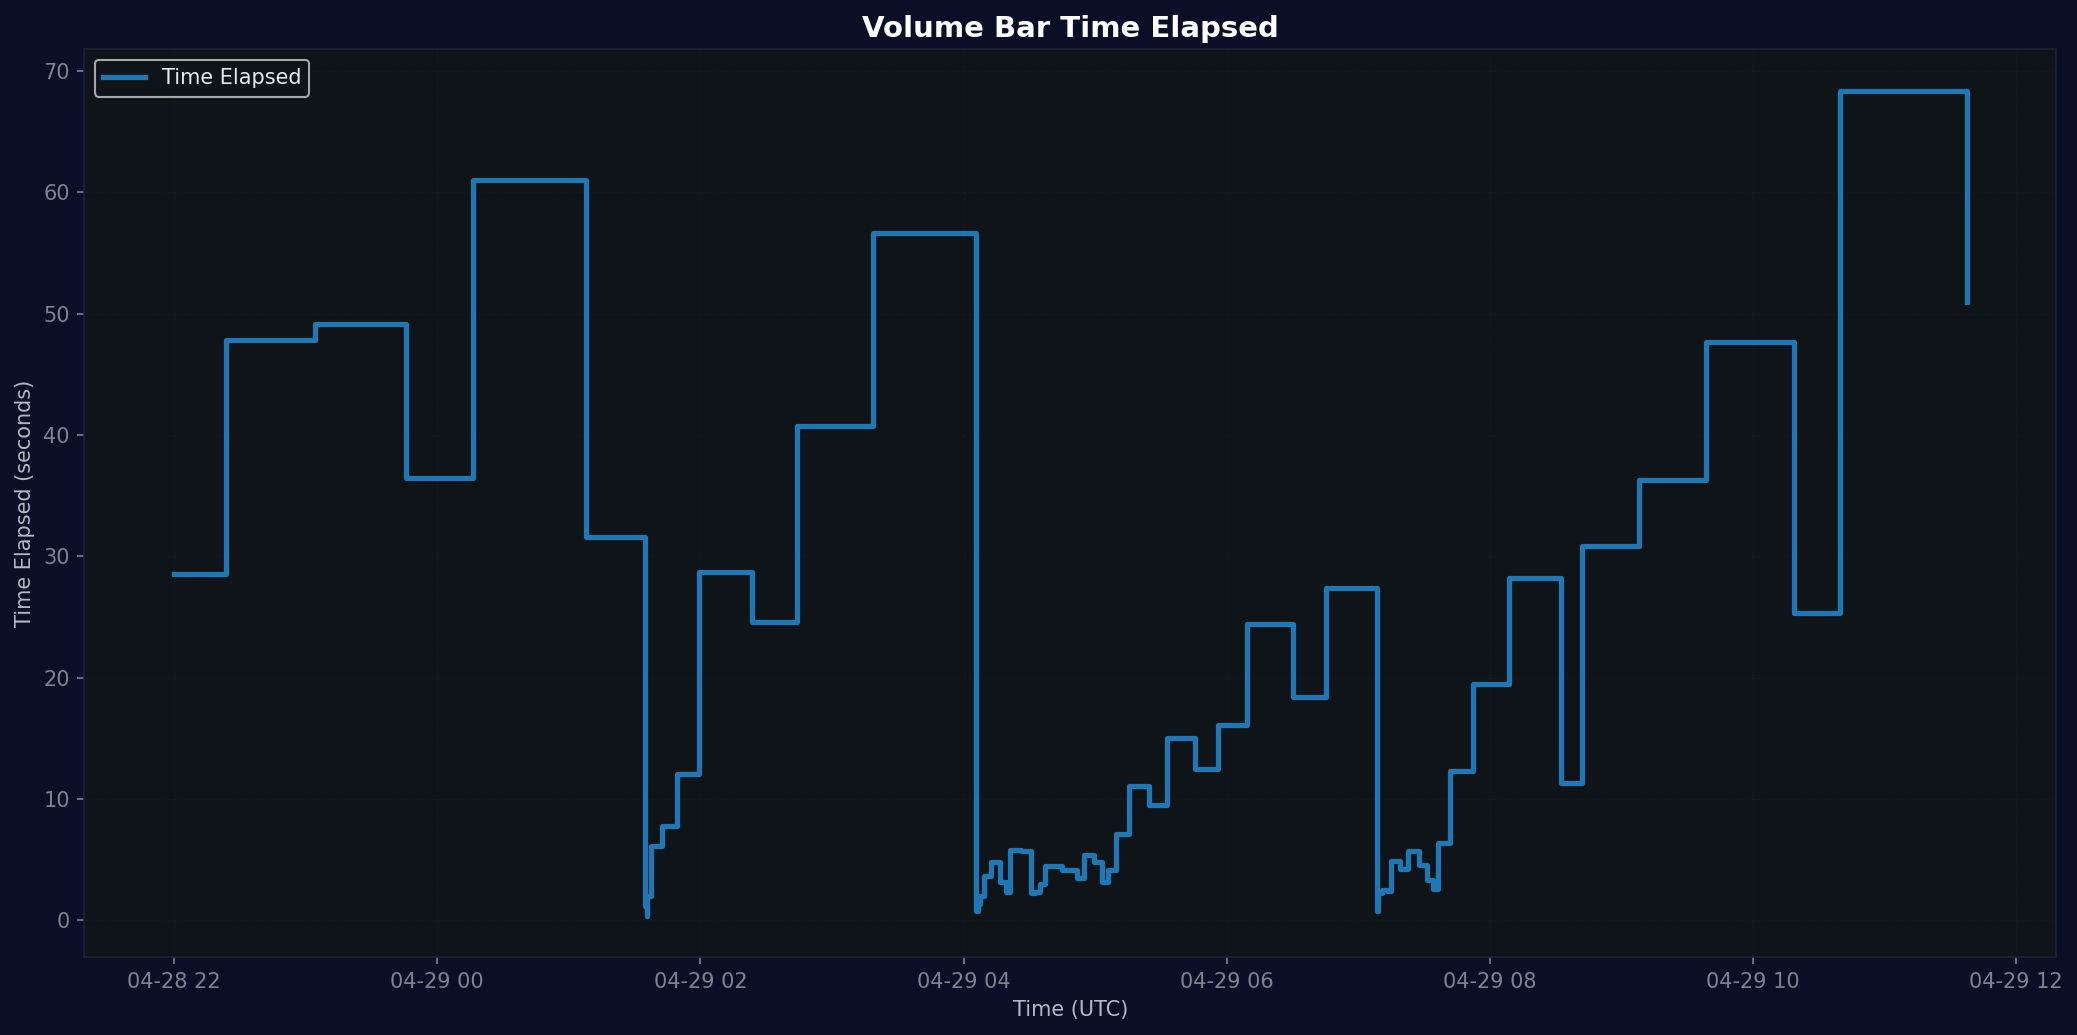

In [30]:

# Sort by start time for proper plotting
vb_plot = vb_lf.sort("start_time")

# Create plot
plt.figure(figsize=(14, 7))
plt.plot(
    vb_plot["start_time"],
    vb_plot["avg_time_elapsed_seconds"],
    drawstyle="steps-post",
    label="Time Elapsed",
)

plt.title("Volume Bar Time Elapsed")
plt.xlabel("Time (UTC)")
plt.ylabel("Time Elapsed (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
def plot_price_and_elapsed(
    price_data: pl.DataFrame,
    vb_data: pl.DataFrame,
    symbol: str,
    tick_size: float,
) -> None:
    """
    Plot VWAP price and volume bar time elapsed on dual y-axes.
    """
    price_min = price_data.select(pl.col("Price").min()).item()
    price_max = price_data.select(pl.col("Price").max()).item()
    
    y_tick_range = np.arange(
        price_min,
        price_max + tick_size,
        tick_size,
    )

    # Sort volume bar data
    vb_data = vb_data.sort("start_time")

    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot price on primary y-axis
    color = "tab:blue"
    ax1.set_xlabel("Time (UTC)")
    ax1.set_ylabel("Price", color=color)
    ax1.plot(
        price_data["ts_recv_dt"],
        price_data["Price"],
        color=color,
        drawstyle="steps-post",
        label="Price",
    )
    ax1.tick_params(axis="y", labelcolor=color)
    ax1.set_yticks(y_tick_range)

    # Create secondary y-axis for time elapsed
    ax2 = ax1.twinx()
    color = "tab:orange"
    ax2.set_ylabel("Time Elapsed (seconds)", color=color)
    ax2.plot(
        vb_data["start_time"],
        vb_data["total_time_elapsed_seconds"],
        color=color,
        drawstyle="steps-post",
        label="Time Elapsed",
    )
    ax2.tick_params(axis="y", labelcolor=color)

    # Title and layout
    plt.title(f"{symbol} Price and Volume Bar Time Elapsed")
    fig.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

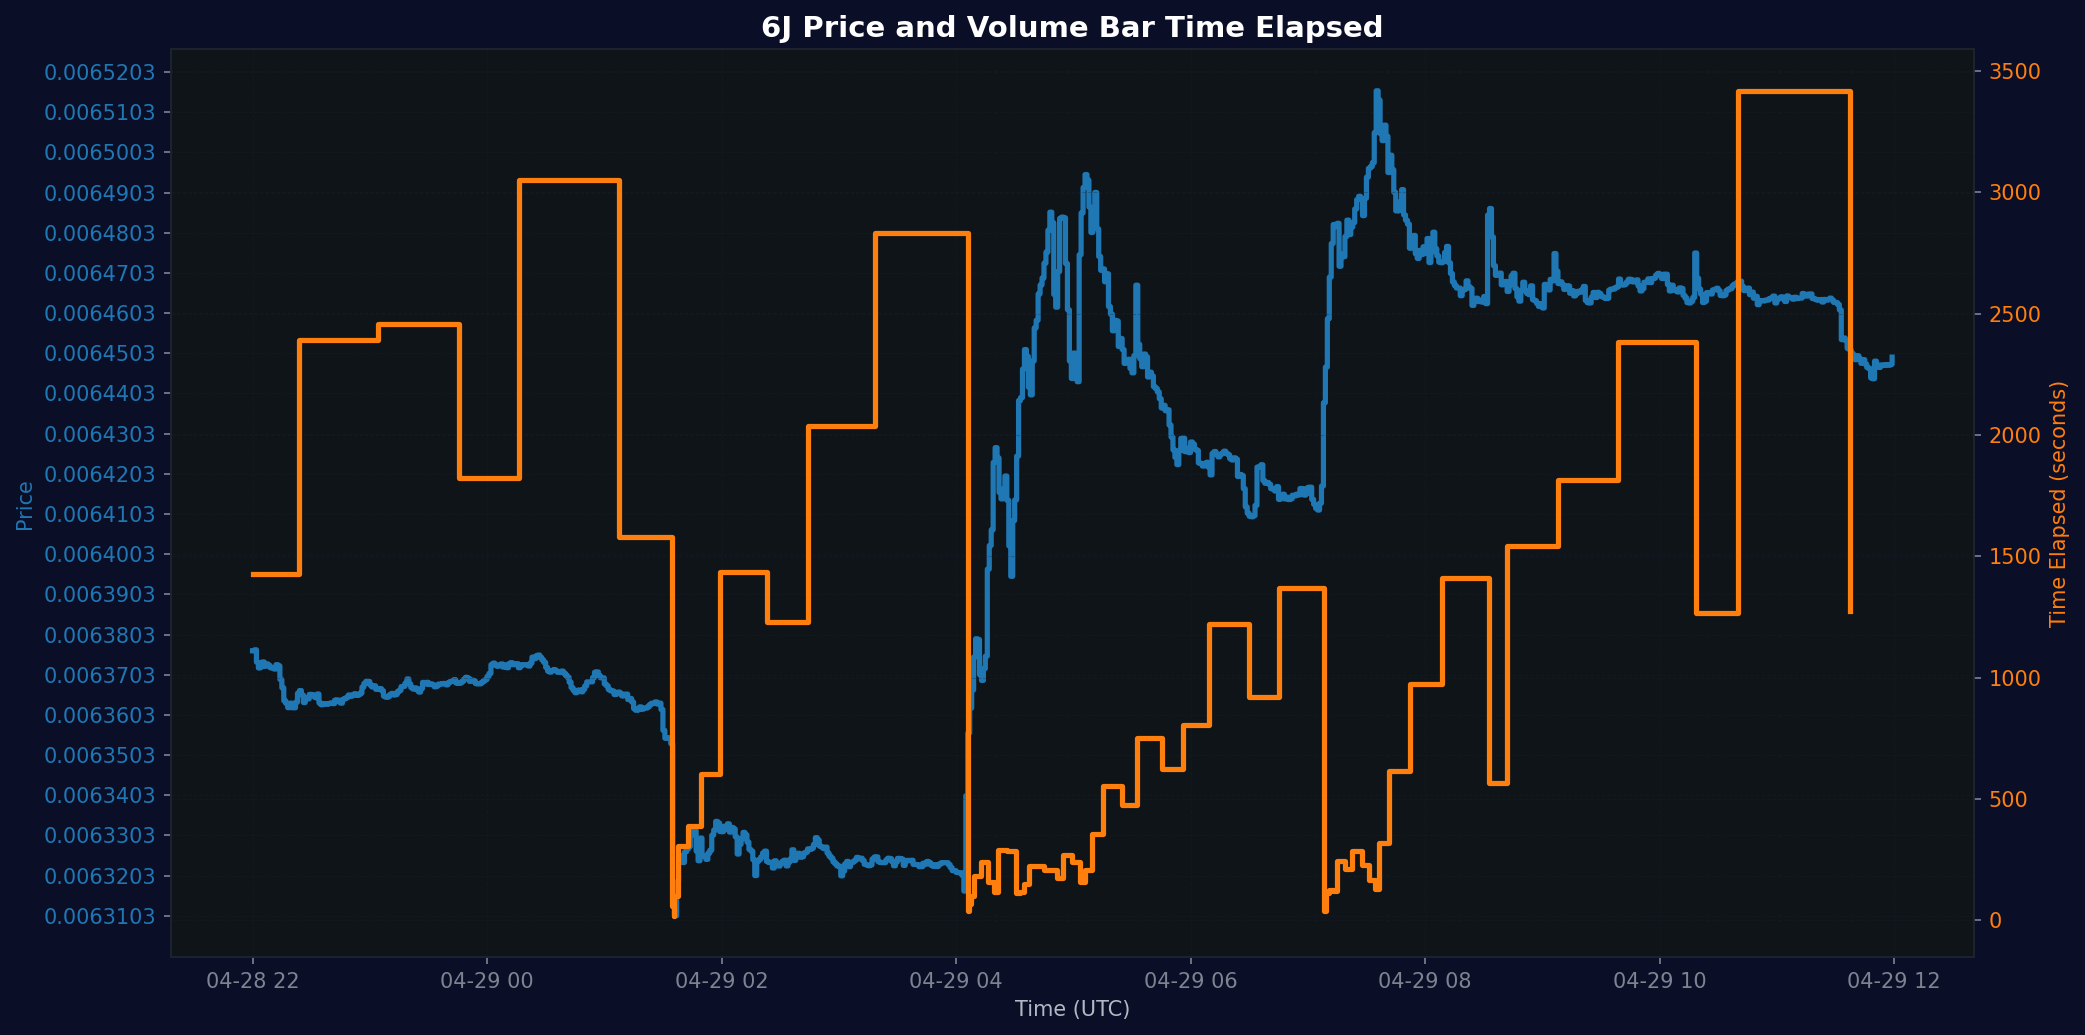

In [32]:
plot_price_and_elapsed(vwap, vb_plot, "6J", TICK_SIZE)

Rows found: 3326
START_DATE_NS: 1714341600000000000
END_DATE_NS: 1714392000000000000


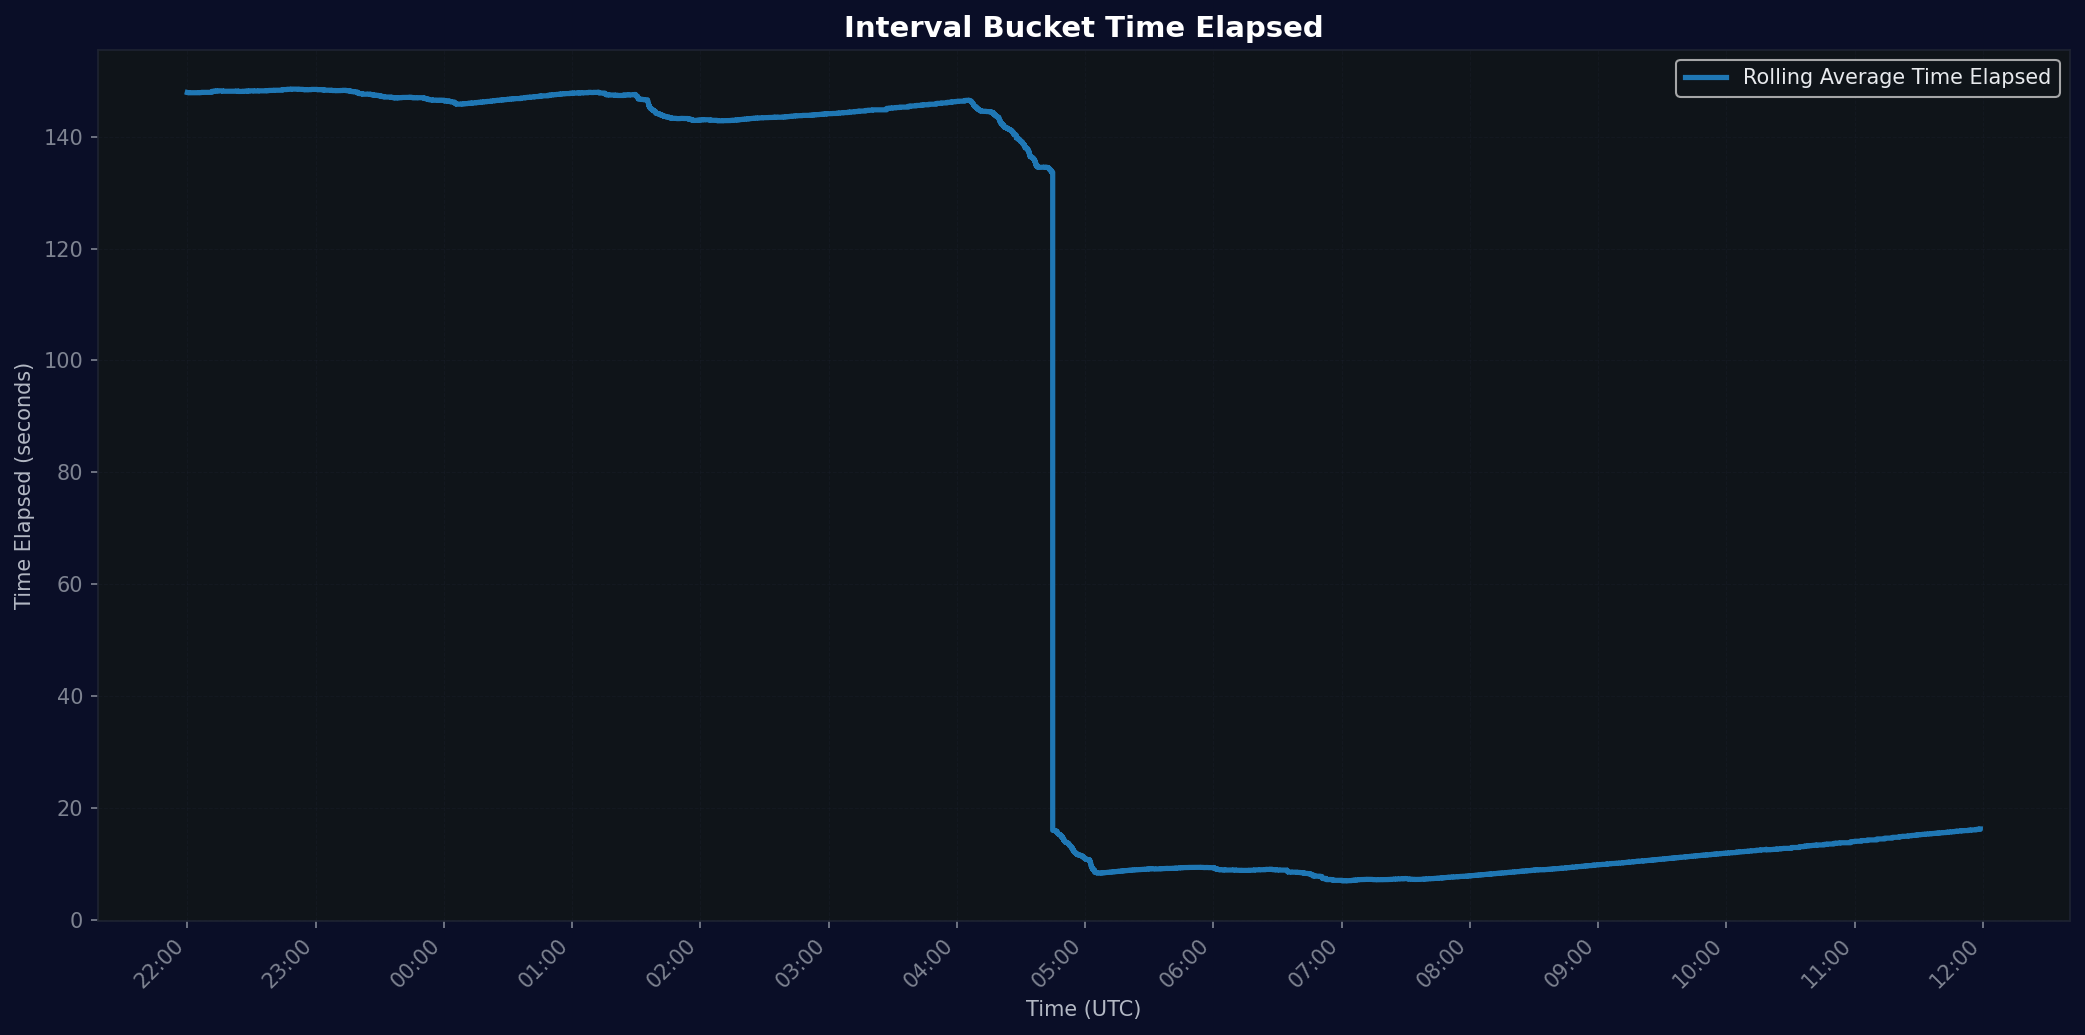

In [33]:

IB1500_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_ib1500/2214_Nov_15_25/bucket/interval/bucket_interval_consolidated.parquet")

# ============================================================================
# [START] - Import Filters
# ============================================================================

# Data files to glob for processing
IB_DATA_GLOB = pl.scan_parquet(str(IB1500_DIR))


# {IntervalBucket - 1500} [ ACTUAL FILTER REQUEST FOR PROCESSING ]

"""

Rolling average container

Container_Size > Search_Range

Thus only consider end time for each new interval of the rolling average that would be available in the time frame

"""


ib_lf = (
    IB_DATA_GLOB
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    .select([
        "id",
        pl.col("start_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("start_ts_ns"),
        pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
        "time_elapsed_ns_total",
        "pace_of_orders_mean",
        "time_elapsed_ns_mean",
        "imbalance_size_signed_ratio_mean",
        "bucket_delta_imbalance_size_abs_ratio_mean_logit",
        "imbalance_size_signed_ratio_atanh_mean",
    ])
    .with_columns([
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_time"),
        (pl.col("time_elapsed_ns_mean") / 1e9).alias("time_elapsed_ns_mean"),
    ])
).collect()

# Debug: Check if data exists in the range
print(f"Rows found: {len(ib_lf)}")
print(f"START_DATE_NS: {START_DATE_NS}")
print(f"END_DATE_NS: {END_DATE_NS}")

# Check actual data range
if len(ib_lf) == 0:
    min_max = IB_DATA_GLOB.select([
        pl.col("start_ts_ns").min().alias("min_start"),
        pl.col("end_ts_ns").max().alias("max_end"),
    ]).collect()
    print(f"Actual data range: {min_max}")




import matplotlib.dates as mdates

# Sort by end time for proper plotting
ib_plot = ib_lf.sort("end_time")

# Create plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(
    ib_plot["end_time"],
    ib_plot["time_elapsed_ns_mean"],
    drawstyle="steps-post",
    label="Rolling Average Time Elapsed",
)

# Format x-axis to show HH:MM in UTC
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=None))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax.set_title("Interval Bucket Time Elapsed")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Time Elapsed (seconds)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

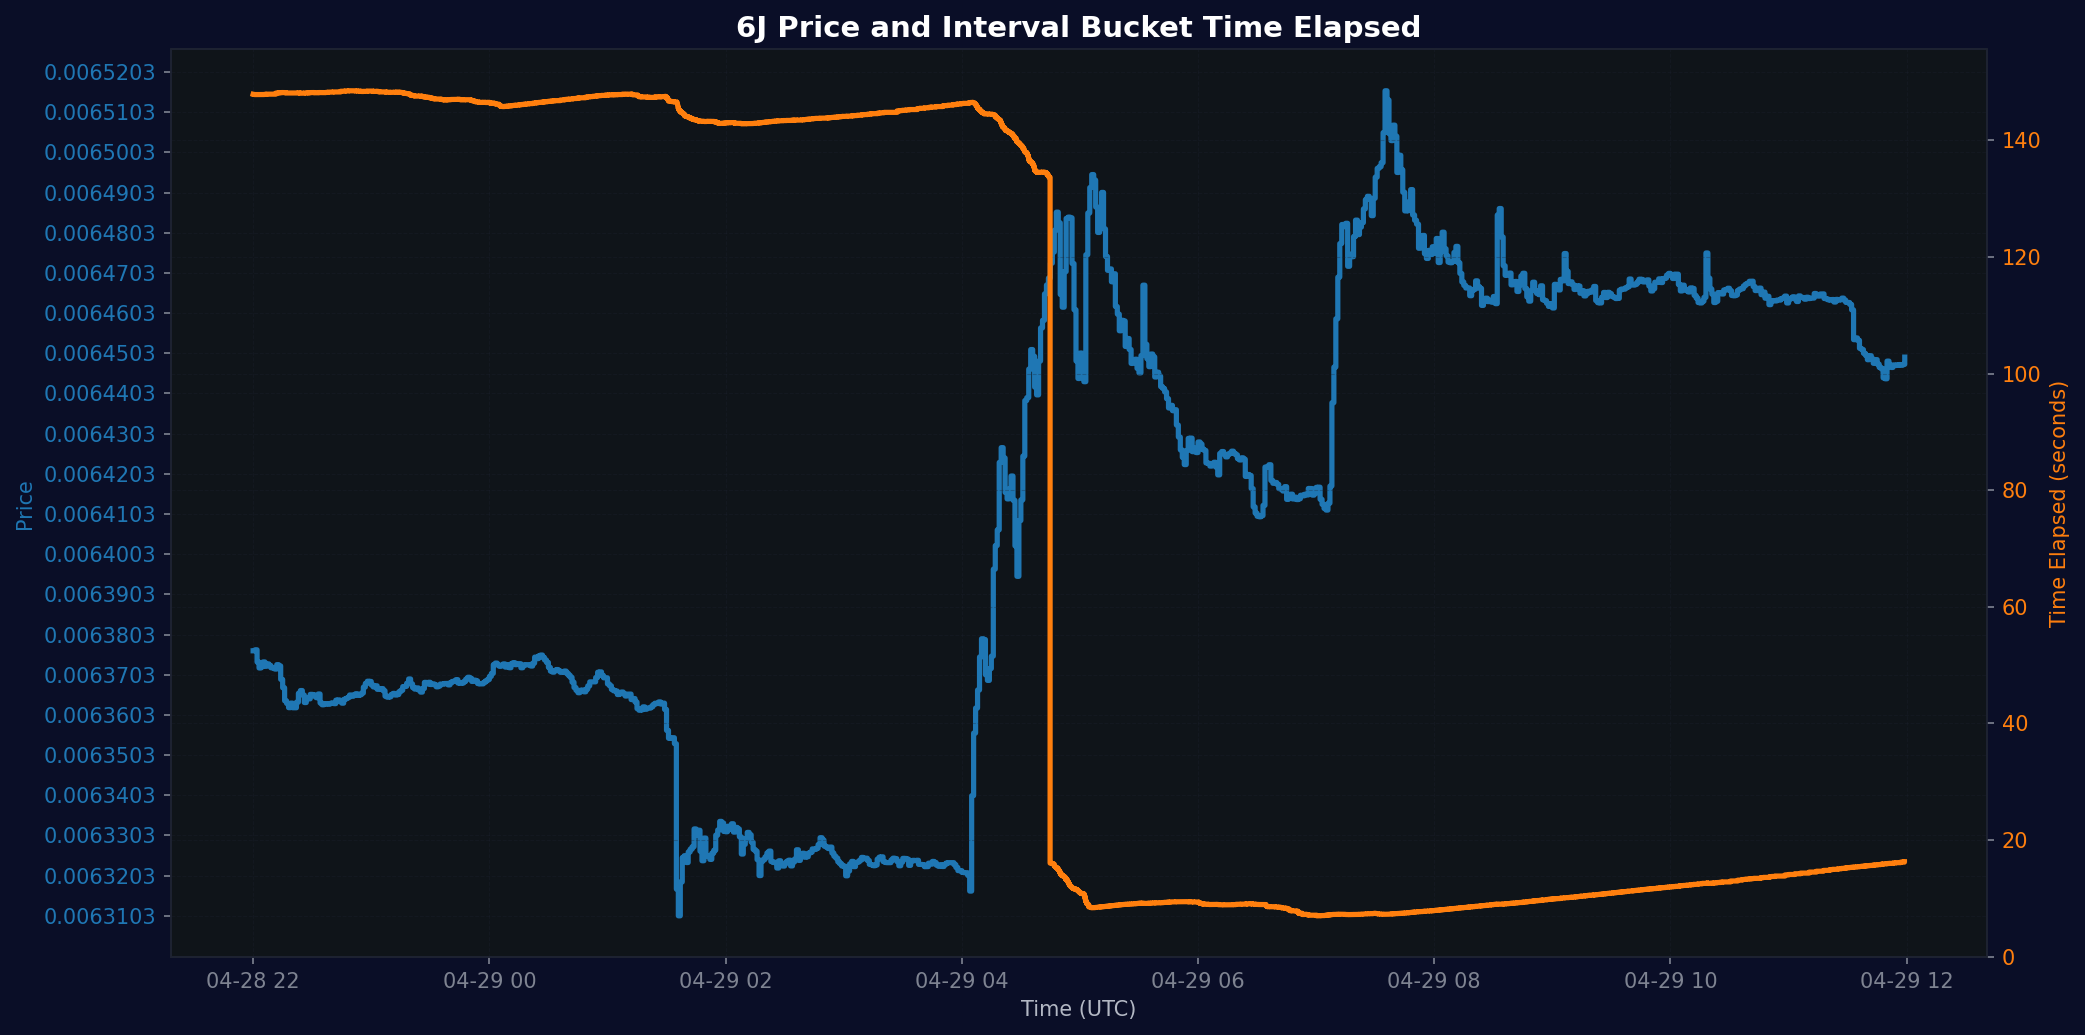

In [34]:
def plot_price_and_elapsed2(
    price_data: pl.DataFrame,
    ib_lf: pl.DataFrame,
    symbol: str,
    tick_size: float,
) -> None:
    """
    Plot VWAP price and volume bar time elapsed on dual y-axes.
    """
    price_min = price_data.select(pl.col("Price").min()).item()
    price_max = price_data.select(pl.col("Price").max()).item()
    
    y_tick_range = np.arange(
        price_min,
        price_max + tick_size,
        tick_size,
    )

    # Sort volume bar data
    ib_lf = ib_lf.sort("end_time")

    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot price on primary y-axis
    color = "tab:blue"
    ax1.set_xlabel("Time (UTC)")
    ax1.set_ylabel("Price", color=color)
    ax1.plot(
        price_data["ts_recv_dt"],
        price_data["Price"],
        color=color,
        drawstyle="steps-post",
        label="Price",
    )
    ax1.tick_params(axis="y", labelcolor=color)
    ax1.set_yticks(y_tick_range)

    # Create secondary y-axis for time elapsed
    ax2 = ax1.twinx()
    color = "tab:orange"
    ax2.set_ylabel("Time Elapsed (seconds)", color=color)
    ax2.plot(
        ib_lf["end_time"],
        ib_lf["time_elapsed_ns_mean"],
        color=color,
        drawstyle="steps-post",
        label="Time Elapsed",
    )
    ax2.tick_params(axis="y", labelcolor=color)

    # Title and layout
    plt.title(f"{symbol} Price and Interval Bucket Time Elapsed")
    fig.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_price_and_elapsed2(vwap, ib_lf, "6J", TICK_SIZE)

In [43]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter


def plot_price_and_elapsed2(
    price_data: pl.DataFrame,
    ib_lf: pl.DataFrame,
    symbol: str,
    tick_size: float,
) -> None:
    """
    Bloomberg-style dual-axis chart:
    - Left Y: VWAP price
    - Right Y: Interval bucket time elapsed
    - X: Intraday time (UTC)
    """

    # -------------------------------------------------------------------------
    # Bloomberg theme
    # -------------------------------------------------------------------------
    plt.rcParams.update({
        "figure.facecolor": "#0a0e27",
        "axes.facecolor": "#0f1419",
        "axes.edgecolor": "#1e2332",
        "axes.labelcolor": "#b3b8c4",
        "axes.titlecolor": "#ffffff",
        "text.color": "#e8eaed",
        "xtick.color": "#7e8391",
        "ytick.color": "#7e8391",
        "grid.color": "#1e2332",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
        "grid.alpha": 0.3,
        "figure.dpi": 150,
        "axes.grid": True,
        "axes.axisbelow": True,
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "lines.linewidth": 2.5,
        "xtick.direction": "out",
        "ytick.direction": "out",
    })

    # -------------------------------------------------------------------------
    # Data prep
    # -------------------------------------------------------------------------
    price_min = price_data.select(pl.col("Price").min()).item()
    price_max = price_data.select(pl.col("Price").max()).item()

    y_tick_range = np.arange(
        price_min,
        price_max + tick_size,
        tick_size,
    )

    ib_lf = ib_lf.sort("end_time")

    x_price = price_data["ts_recv_dt"].to_numpy()
    y_price = price_data["Price"].to_numpy()

    x_elapsed = ib_lf["end_time"].to_numpy()
    y_elapsed = ib_lf["time_elapsed_ns_mean"].to_numpy()

    # -------------------------------------------------------------------------
    # Formatters
    # -------------------------------------------------------------------------
    def price_formatter(x: float, pos: int) -> str:
        # FX-friendly: more decimals if tick is very small
        if abs(tick_size) < 0.01:
            return f"{x:,.4f}"
        return f"{x:,.2f}"

    def elapsed_formatter(x: float, pos: int) -> str:
        # Time elapsed in seconds with thousands separator
        return f"{x:,.2f}"

    # -------------------------------------------------------------------------
    # Figure and axes
    # -------------------------------------------------------------------------
    fig, ax_price = plt.subplots(
        figsize=(14, 8),
        facecolor="#0a0e27",
    )

    # Price axis (left)
    price_color = "#00d4aa"  # teal
    ax_price.plot(
        x_price,
        y_price,
        color=price_color,
        drawstyle="steps-post",
        label="Price",
        antialiased=True,
    )
    ax_price.set_ylabel("Price", color=price_color)
    ax_price.tick_params(axis="y", colors=price_color)
    ax_price.set_yticks(y_tick_range)
    ax_price.yaxis.set_major_formatter(FuncFormatter(price_formatter))

    # Put price axis on left (style guide dual-axis exception)
    ax_price.yaxis.set_label_position("left")
    ax_price.yaxis.tick_left()

    # Format X-axis as intraday time
    ax_price.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.setp(ax_price.xaxis.get_majorticklabels(), rotation=45, ha="right")

    # Subtle spines
    for spine in ax_price.spines.values():
        spine.set_color("#1e2332")

    # -------------------------------------------------------------------------
    # Time elapsed axis (right)
    # -------------------------------------------------------------------------
    ax_elapsed = ax_price.twinx()
    elapsed_color = "#ffd93d"  # yellow
    ax_elapsed.plot(
        x_elapsed,
        y_elapsed,
        color=elapsed_color,
        drawstyle="steps-post",
        label="Time Elapsed",
        antialiased=True,
        linewidth=2.0,
    )
    ax_elapsed.set_ylabel("Time Elapsed (seconds)", color=elapsed_color)
    ax_elapsed.tick_params(axis="y", colors=elapsed_color)
    ax_elapsed.yaxis.set_major_formatter(FuncFormatter(elapsed_formatter))
    ax_elapsed.yaxis.set_label_position("right")
    ax_elapsed.yaxis.tick_right()

    for spine in ax_elapsed.spines.values():
        spine.set_color("#1e2332")

    # -------------------------------------------------------------------------
    # Title, legend, grid
    # -------------------------------------------------------------------------
    ax_price.set_title(f"{symbol} Price and Interval Bucket Time Elapsed")

    # Combined legend from both axes
    handles_p, labels_p = ax_price.get_legend_handles_labels()
    handles_e, labels_e = ax_elapsed.get_legend_handles_labels()
    if handles_p or handles_e:
        legend = ax_price.legend(
            handles_p + handles_e,
            labels_p + labels_e,
            loc="upper right",
            framealpha=0.95,
            facecolor="#0f1419",
            edgecolor="#1e2332",
            fontsize=9,
        )
        for text in legend.get_texts():
            text.set_color("#e8eaed")

    # Prefer horizontal grid lines
    ax_price.grid(True, axis="y")
    ax_price.grid(False, axis="x")

    fig.tight_layout()
    plt.show()


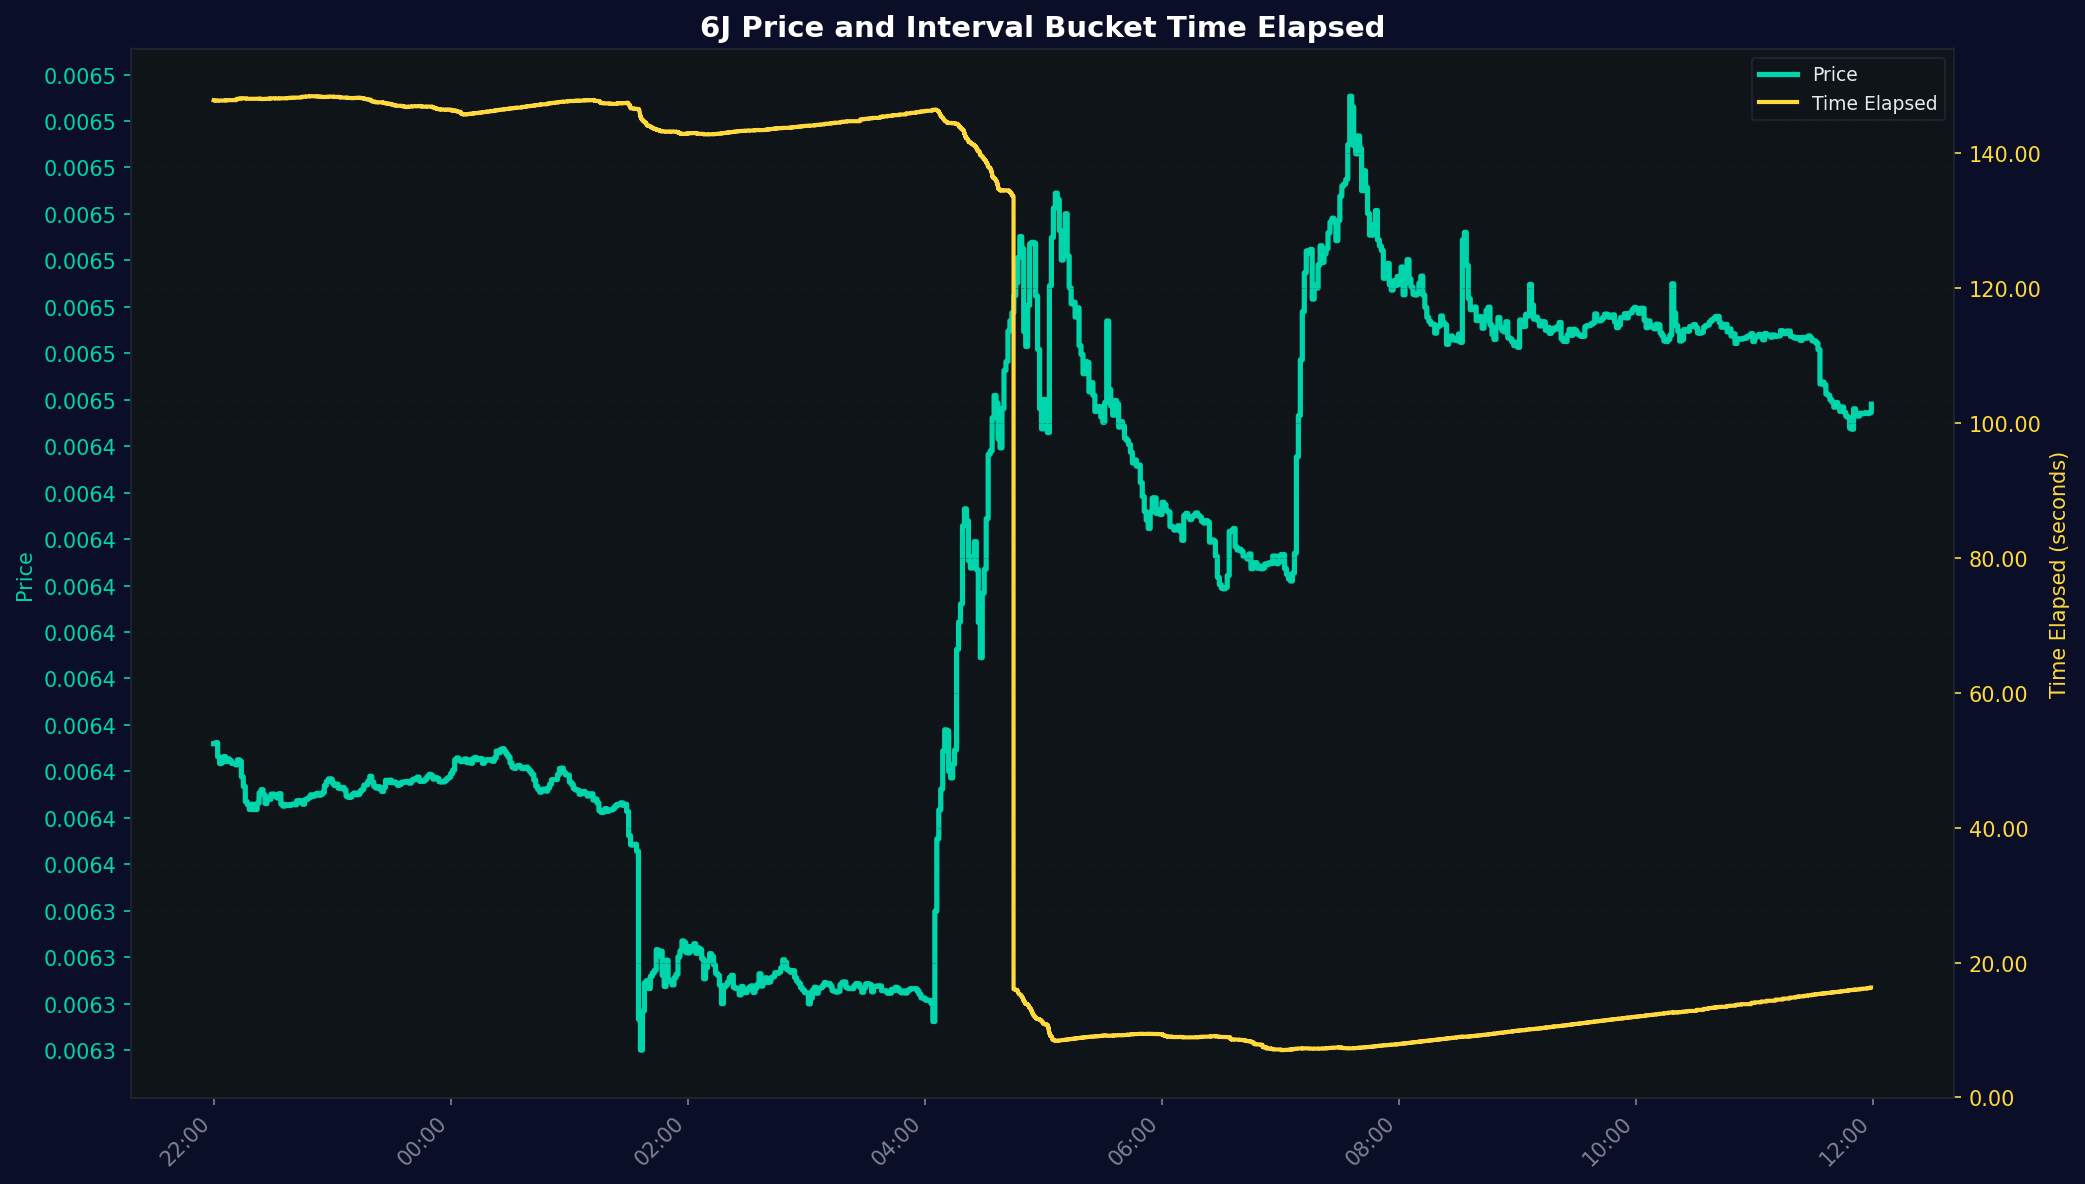

In [44]:
plot_price_and_elapsed2(vwap, ib_lf, "6J", TICK_SIZE)